# Arquitetura do Modelo 3

## Etapa 1 - Importando as bibliotecas

In [25]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.5 MB)
Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.5 MB)


In [26]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import zipfile

cv2.__version__

'4.10.0'

'4.10.0'

In [27]:
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [28]:
!pip install tf_keras

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [29]:
from google.colab import drive
drive.mount('/content/gdrive')  # Conecta o Google Drive
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip"  # Define o caminho do arquivo Material.zip
zip_object = zipfile.ZipFile(file=path, mode="r")  # Abre o arquivo ZIP em modo de leitura
zip_object.extractall("./")  # Extrai os arquivos para o diretório atual
base_imgs = 'Material/fer2013.zip'  # Define o caminho do arquivo fer2013.zip
zip_object = zipfile.ZipFile(file = base_imgs, mode = "r")  # Abre o arquivo com as imagens em modo de leitura
zip_object.extractall("./")
zip_object.close()  # Fecha o arquivo ZIP

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Etapa 3 - Acessando a base com fotos de expressões faciais



In [30]:
data = pd.read_csv('fer2013/fer2013.csv')  # Carrega o arquivo CSV com os dados do FER2013
data.tail()  # Exibe as últimas linhas do conjunto de dados

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


Text(0.5, 1.0, 'Imagens x emoção')

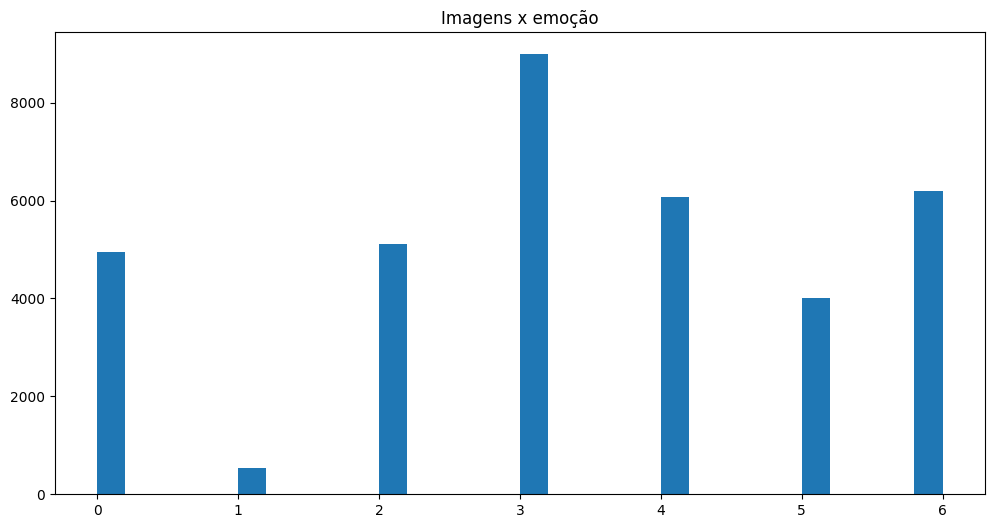

Text(0.5, 1.0, 'Imagens x emoção')

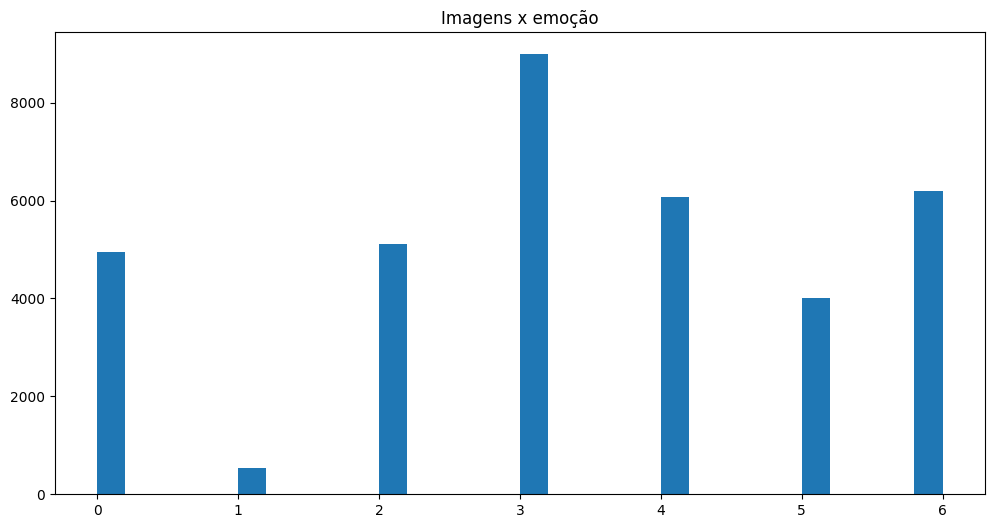

In [31]:
plt.figure(figsize=(12,6))  # Define o tamanho do gráfico
plt.hist(data['emotion'], bins=30)  # Cria um histograma com a quantidade de imagens por emoção
plt.title("Imagens x emoção")  # Define o título do gráfico

# Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

## Etapa 4 - Pré-processamento

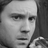

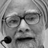

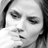

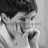

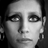

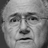

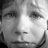

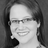

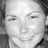

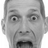

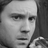

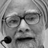

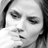

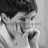

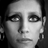

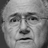

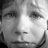

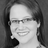

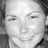

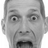

In [32]:
pixels = data['pixels'].tolist()  # Pega os pixels das imagens
largura, altura = 48, 48
faces = []
amostras = 0

for pixel_sequence in pixels:
  face = [int(pixel) for pixel in pixel_sequence.split(' ')]
  face = np.asarray(face).reshape(largura, altura)  # Transforma os pixels em imagem 48x48
  faces.append(face)

  if (amostras < 10):
    cv2_imshow(face)  # Exibe as primeiras imagens

  amostras = amostras + 1

faces = np.asarray(faces)
faces = np.expand_dims(faces, -1)  # Adiciona a dimensão do canal

def normalizar(x, v2=True):
    x = x.astype('float32')
    x = x / 255.0  # Normaliza os valores entre 0 e 1
    return x

faces = normalizar(faces)

emocoes = pd.get_dummies(data['emotion']).values

In [33]:
print("Número total de imagens no dataset: "+str(len(faces)))

Número total de imagens no dataset: 35887
Número total de imagens no dataset: 35887


## Etapa 5 - Imports do Tensorflow/Keras

In [34]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, TensorBoard, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

## Etapa 6 - Dividir em conjuntos para treinamento e validação

In [35]:
x_train, x_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)  # Separa treino e teste
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=41)  # Separa parte do treino para validação

print("Número de imagens no conjunto de treinamento:", len(x_train))
print("Número de imagens no conjunto de testes:", len(x_test))
print("Número de imagens no conjunto de validação:", len(y_val))

Número de imagens no conjunto de treinamento: 29068
Número de imagens no conjunto de testes: 3589
Número de imagens no conjunto de validação: 3230
Número de imagens no conjunto de treinamento: 29068
Número de imagens no conjunto de testes: 3589
Número de imagens no conjunto de validação: 3230


In [36]:
np.save('mod_xtest', x_test)  # Salva as imagens de teste
np.save('mod_ytest', y_test)  # Salva as classes de teste

## Etapa 7 - Arquitetura do Modelo (CNN)

### Arquitetura do modelo

Implementação original: https://medium.com/themlblog/how-to-do-facial-emotion-recognition-using-a-cnn-b7bbae79cd8f

In [37]:
from tensorflow.keras import optimizers

epochs = 100
batch_size = 64
learning_rate = 0.001
model = Sequential()  # Cria o modelo sequencial

# Primeiro bloco convolucional
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1), kernel_regularizer=l2(0.01)))
model.add(Conv2D(64, (3, 3), padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2, 2)))
model.add(Dropout(0.5))

# Segundo bloco convolucional
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

# Terceiro bloco convolucional
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

# Quarto bloco convolucional
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Flatten())  # Transforma os dados em um vetor

# Camadas densas para classificação
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))  # Camada de saída para as 7 emoções

adam = optimizers.Adam(learning_rate = learning_rate)
model.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])  # Compila o modelo

print(model.summary())  # Exibe a arquitetura do modelo

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,014,727 (34.39 MB)

 Trainable params: 9,009,223 (34.37 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,014,727 (34.39 MB)

 Trainable params: 9,009,223 (34.37 MB)

 Non-trainable params: 5,504 (21.50 KB)

None


## Etapa 8 - Compilando o modelo

In [38]:
model.compile(loss=categorical_crossentropy,
              optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
              metrics=['accuracy'])  # Configura o modelo para o treinamento

arquivo_modelo = "modelo_04_expressoes.h5"
arquivo_modelo_json = "modelo_4_expressoes.json"
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1)  # Reduz a taxa de aprendizado quando não há melhora
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto')  # Interrompe o treinamento se não houver melhora
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)  # Salva o melhor modelo

### Salvando a arquitetura do modelo em um arquivo JSON

In [39]:
model_json = model.to_json()  # Converte a estrutura do modelo para JSON
with open(arquivo_modelo_json, "w") as json_file:
    json_file.write(model_json)  # Salva a arquitetura do modelo no arquivo JSON

## Etapa 9 - Treinando o modelo

In [40]:
history = model.fit(np.array(x_train), np.array(y_train),  # Inicia o treinamento do modelo
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(np.array(x_val), np.array(y_val)),  # Usa os dados de validação durante o treinamento
          shuffle=True,
          callbacks=[lr_reducer, early_stopper, checkpointer])  # Aplica os callbacks configurados

Epoch 1/100
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1847 - loss: 2.4778
Epoch 1: val_loss improved from None to 1.83435, saving model to modelo_04_expressoes.h5



Epoch 1: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 73s 107ms/step - accuracy: 0.2007 - loss: 2.0597 - val_accuracy: 0.2594 - val_loss: 1.8343 - learning_rate: 0.0010
Epoch 2/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2295 - loss: 1.8686
Epoch 2: val_loss improved from 1.83435 to 1.82199, saving model to modelo_04_expressoes.h5



Epoch 2: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.2374 - loss: 1.8575 - val_accuracy: 0.2594 - val_loss: 1.8220 - learning_rate: 0.0010
Epoch 3/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2467 - loss: 1.8404
Epoch 3: val_loss improved from 1.82199 to 1.81438, saving model to modelo_04_expressoes.h5



Epoch 3: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.2474 - loss: 1.8384 - val_accuracy: 0.2594 - val_loss: 1.8144 - learning_rate: 0.0010
Epoch 4/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2512 - loss: 1.8298
Epoch 4: val_loss improved from 1.81438 to 1.80855, saving model to modelo_04_expressoes.h5



Epoch 4: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.2502 - loss: 1.8287 - val_accuracy: 0.2594 - val_loss: 1.8086 - learning_rate: 0.0010
Epoch 5/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2518 - loss: 1.8205
Epoch 5: val_loss improved from 1.80855 to 1.79905, saving model to modelo_04_expressoes.h5


...


Epoch 30: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.5610 - loss: 1.1557 - val_accuracy: 0.5641 - val_loss: 1.1748 - learning_rate: 8.1000e-04
Epoch 31/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5691 - loss: 1.1178
Epoch 31: val_loss did not improve from 1.17479
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.5701 - loss: 1.1306 - val_accuracy: 0.5560 - val_loss: 1.1780 - learning_rate: 8.1000e-04
Epoch 32/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5753 - loss: 1.1009
Epoch 32: val_loss improved from 1.17479 to 1.15267, saving model to modelo_04_expressoes.h5



Epoch 32: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.5799 - loss: 1.1039 - val_accuracy: 0.5678 - val_loss: 1.1527 - learning_rate: 8.1000e-04
Epoch 33/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5912 - loss: 1.0869
Epoch 33: val_loss improved from 1.15267 to 1.12962, saving model to modelo_04_expressoes.h5



Epoch 33: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.5923 - loss: 1.0844 - val_accuracy: 0.5796 - val_loss: 1.1296 - learning_rate: 8.1000e-04
Epoch 34/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5905 - loss: 1.0746
Epoch 34: val_loss did not improve from 1.12962
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.5938 - loss: 1.0763 - val_accuracy: 0.5755 - val_loss: 1.1575 - learning_rate: 8.1000e-04
Epoch 35/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6055 - loss: 1.0430
Epoch 35: val_loss did not improve from 1.12962
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.6039 - loss: 1.0472 - val_accuracy: 0.5839 - val_loss: 1.1380 - learning_rate: 8.1000e-04
Epoch 36/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6114 - loss: 1.0294
Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0007290000503417104.

Epoch 36: val_loss did not improve from 1.12962
455/455 ━━


Epoch 37: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.6247 - loss: 1.0036 - val_accuracy: 0.6034 - val_loss: 1.0955 - learning_rate: 7.2900e-04
Epoch 38/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6319 - loss: 0.9860
Epoch 38: val_loss did not improve from 1.09553
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.6351 - loss: 0.9843 - val_accuracy: 0.5944 - val_loss: 1.1418 - learning_rate: 7.2900e-04
Epoch 39/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6390 - loss: 0.9817
Epoch 39: val_loss did not improve from 1.09553
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.6372 - loss: 0.9798 - val_accuracy: 0.5988 - val_loss: 1.1241 - learning_rate: 7.2900e-04
Epoch 40/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6533 - loss: 0.9440
Epoch 40: val_loss improved from 1.09553 to 1.09184, saving model to modelo_04_expressoes.h5



Epoch 40: finished saving model to modelo_04_expressoes.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.6448 - loss: 0.9570 - val_accuracy: 0.6161 - val_loss: 1.0918 - learning_rate: 7.2900e-04
Epoch 41/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6603 - loss: 0.9229
Epoch 41: val_loss did not improve from 1.09184
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.6538 - loss: 0.9397 - val_accuracy: 0.5923 - val_loss: 1.1505 - learning_rate: 7.2900e-04
Epoch 42/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6587 - loss: 0.9216
Epoch 42: val_loss did not improve from 1.09184
455/455 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.6573 - loss: 0.9228 - val_accuracy: 0.6034 - val_loss: 1.1576 - learning_rate: 7.2900e-04
Epoch 43/100
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6737 - loss: 0.8942
Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0006561000715009868.

Epoch 43: val_loss did not improve from 1.09184
455/455 ━━

## Gerando gráfico da melhora em cada etapa do treinamento

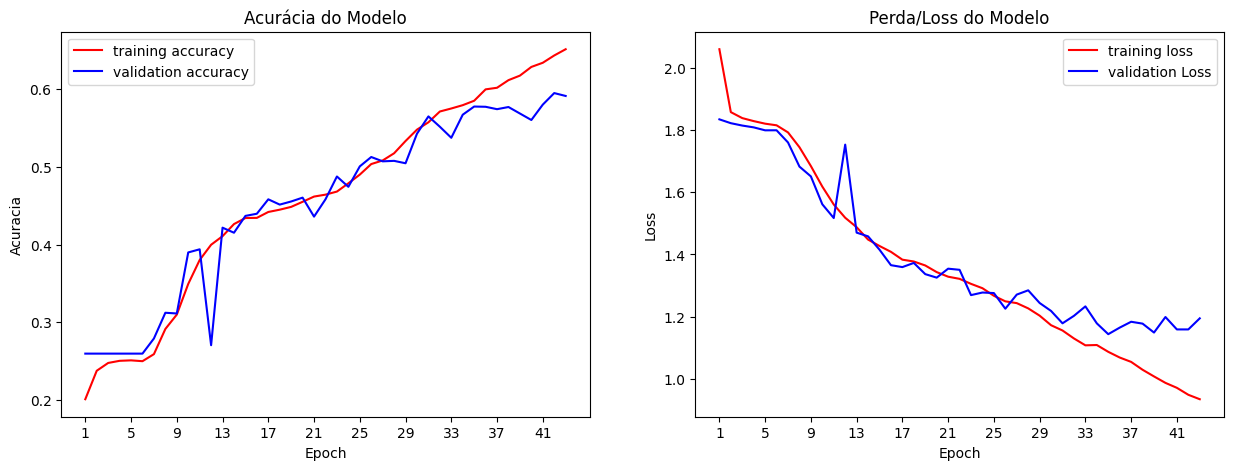

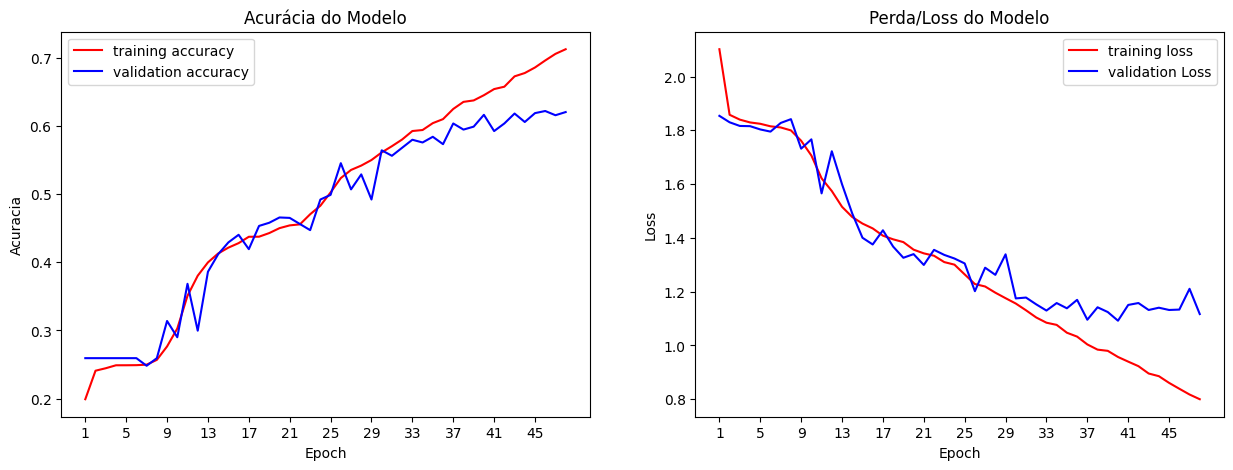

In [41]:
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(1,2,figsize=(15,5))  # Cria os gráficos de acurácia e perda
    axs[0].plot(range(1,len(historico_modelo.history['accuracy'])+1),
                historico_modelo.history['accuracy'],'r')
    axs[0].plot(range(1,len(historico_modelo.history['val_accuracy'])+1),
                historico_modelo.history['val_accuracy'],'b')
    axs[0].set_title('Acurácia do Modelo')
    axs[0].set_ylabel('Acuracia')
    axs[0].set_xlabel('Epoch')
    axs[0].set_xticks(np.arange(1,
                               len(historico_modelo.history['accuracy'])+1,
                               max(1, len(historico_modelo.history['accuracy'])//10)))
    axs[0].legend(['training accuracy', 'validation accuracy'], loc='best')

    axs[1].plot(range(1,len(historico_modelo.history['loss'])+1),
                historico_modelo.history['loss'],'r')
    axs[1].plot(range(1,len(historico_modelo.history['val_loss'])+1),
                historico_modelo.history['val_loss'],'b')
    axs[1].set_title('Perda/Loss do Modelo')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(np.arange(1,
                               len(historico_modelo.history['loss'])+1,
                               max(1, len(historico_modelo.history['loss'])//10)))
    axs[1].legend(['training loss', 'validation Loss'], loc='best')
    fig.savefig('historico_modelo_mod01.png')  # Salva o gráfico gerado
    plt.show()

plota_historico_modelo(history)  # Exibe o histórico do treinamento

### Verificando a acurácia do modelo

In [42]:
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Acurácia: " + str(scores[1]))
print("Perda/Loss: " + str(scores[0]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5709 - loss: 1.1912
Acurácia: 0.5709111094474792
Perda/Loss: 1.191168189048767
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6046 - loss: 1.1746
Acurácia: 0.6046252250671387
Perda/Loss: 1.1746439933776855


## Carregaremos os dados para gerar a matriz de confusão

In [43]:
true_y=[]
pred_y=[]

x = np.load('mod_xtest.npy')  # Carrega as imagens de teste
y = np.load('mod_ytest.npy')  # Carrega as classes reais
json_file = open(arquivo_modelo_json, 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)  # Reconstrói o modelo pelo JSON
loaded_model.load_weights(arquivo_modelo)  # Carrega os pesos do modelo
y_pred= loaded_model.predict(x)  # Realiza as previsões
yp = y_pred.tolist()
yt = y.tolist()
count = 0

for i in range(len(y)):
    yy = max(yp[i])
    yyt = max(yt[i])
    pred_y.append(yp[i].index(yy))
    true_y.append(yt[i].index(yyt))

    if(yp[i].index(yy)== yt[i].index(yyt)):
        count+=1

acc = (count/len(y))*100  # Calcula a acurácia no conjunto de teste

np.save('truey__mod01', true_y)
np.save('predy__mod01', pred_y)
print("Acurácia no conjunto de testes: "+str(acc)+"%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
Acurácia no conjunto de testes: 57.2025633881304%
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Acurácia no conjunto de testes: 59.79381443298969%


## Gerando a Matriz de Confusão

In [44]:
from sklearn.metrics import confusion_matrix

y_true = np.load('truey__mod01.npy')  # Carrega os valores reais
y_pred = np.load('predy__mod01.npy')  # Carrega os valores previstos
cm = confusion_matrix(y_true, y_pred)  # Gera a matriz de confusão
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]
titulo='Matriz de Confusão'
print(cm)  # Exibe a matriz

[[122   0  43  35 214   7  77]
 [ 27   0   2   1  20   0   2]
 [ 39   0 156  39 215  21  75]
 [  4   0   9 787  28   6  47]
 [ 13   0  26  29 356   0 164]
 [  4   0 106  47   8 229  20]
 [  1   0  11  40 154   2 403]]
[[174   0  45  28 168   6  77]
 [ 36   0   4   0  12   0   0]
 [ 47   0 149  47 187  40  75]
 [  6   0  15 777  25   8  50]
 [ 11   0  28  45 362   1 141]
 [  5   0  68  54  12 261  14]
 [  1   0  18  43 125   1 423]]


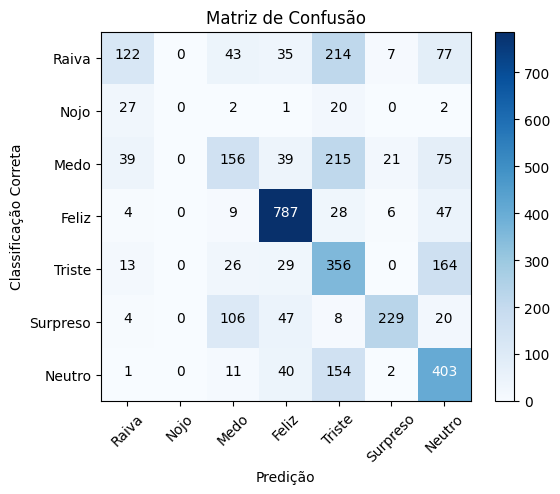

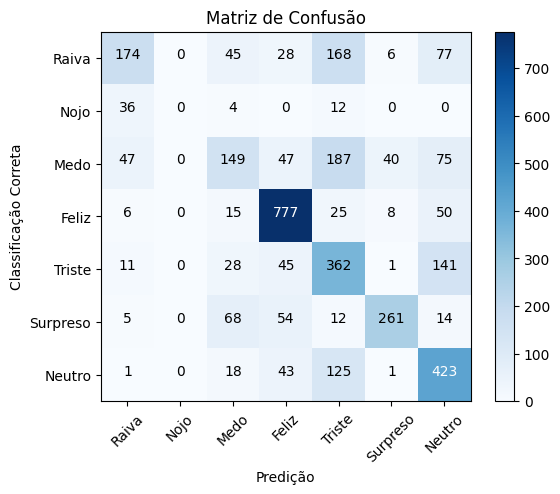

In [45]:
import itertools

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)  # Exibe a matriz de confusão
plt.title(titulo)
plt.colorbar()
tick_marks = np.arange(len(expressoes))
plt.xticks(tick_marks, expressoes, rotation=45)
plt.yticks(tick_marks, expressoes)
fmt = 'd'
thresh = cm.max() / 2.

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")  # Escreve os valores dentro da matriz

plt.ylabel('Classificação Correta')
plt.xlabel('Predição')
plt.savefig('matriz_confusao_mod01.png')  # Salva a matriz como imagem
plt.show()

## Testando brevemente o modelo

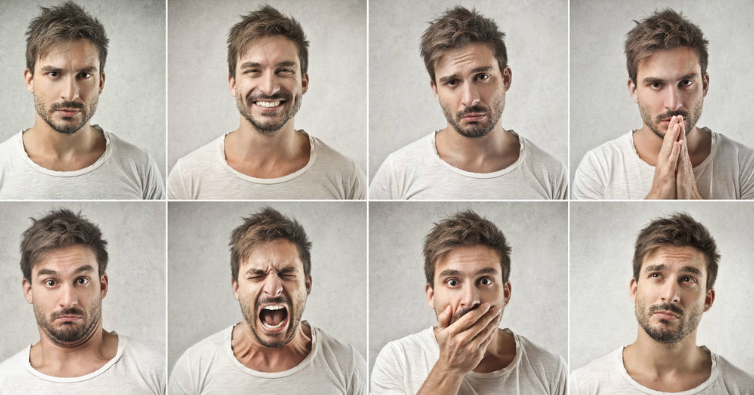

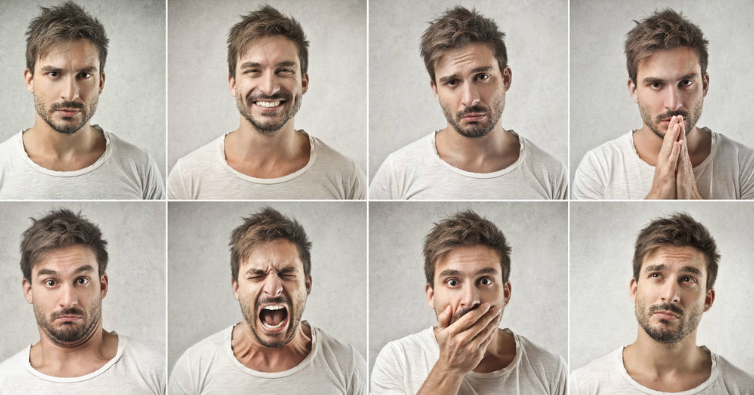

In [46]:
imagem = cv2.imread("Material/testes/teste02.jpg")  # Carrega a imagem para o teste
cv2_imshow(imagem)  # Exibe a imagem

In [47]:
model = load_model("modelo_04_expressoes.h5") # carrega o modelo
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Perda/Loss: " + str(scores[0]))
print("Acurácia: " + str(scores[1]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5720 - loss: 1.1811
Perda/Loss: 1.181061029434204
Acurácia: 0.5720256567001343


57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5979 - loss: 1.1087
Perda/Loss: 1.1087247133255005
Acurácia: 0.5979381203651428


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


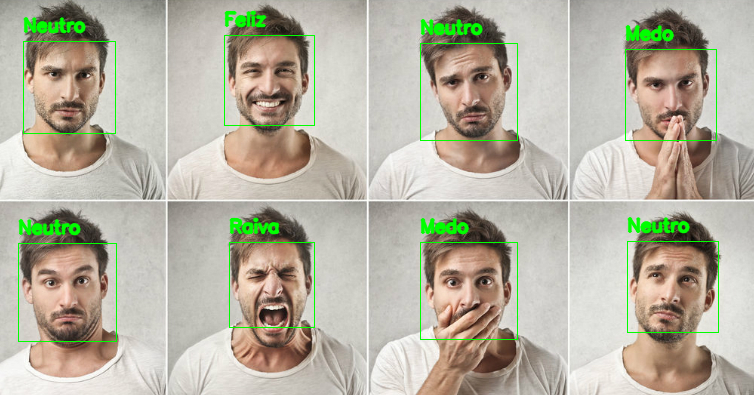

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


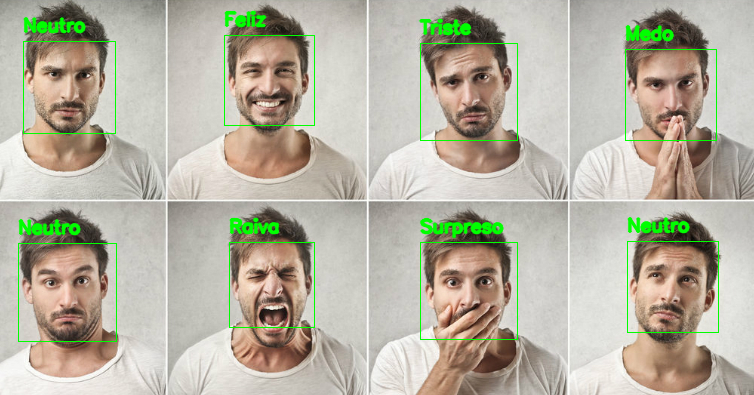

In [48]:
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

original = imagem.copy()  # Faz uma cópia da imagem original
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)  # Converte a imagem para escala de cinza
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml')  # Carrega o detector de faces
faces = face_cascade.detectMultiScale(gray, 1.1, 3)  # Detecta as faces na imagem

for (x, y, w, h) in faces:
    cv2.rectangle(original, (x, y), (x + w, y + h), (0, 255, 0), 1)
    roi_gray = gray[y:y + h, x:x + w]  # Recorta a região do rosto
    roi_gray = roi_gray.astype("float") / 255.0  # Normaliza os pixels
    cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (48, 48)), -1), 0)

    cv2.normalize(cropped_img, cropped_img, alpha=0, beta=1,
                  norm_type=cv2.NORM_L2, dtype=cv2.CV_32F)

    prediction = model.predict(cropped_img)[0]  # Faz a predição da emoção
    cv2.putText(original, expressoes[int(np.argmax(prediction))], (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

cv2_imshow(original)  # Exibe o resultado